In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix , classification_report


In [2]:
df = pd.read_csv("teleco customer churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.shape 

(7043, 21)

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df["TotalCharges"].value_counts().head(10)

TotalCharges
20.2     11
         11
19.75     9
19.65     8
19.9      8
20.05     8
19.55     7
45.3      7
19.45     6
20.25     6
Name: count, dtype: int64

In [9]:
df["TotalCharges"].dtype

dtype('O')

In [10]:
df["TotalCharges"].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

In [11]:
df[df["TotalCharges"].str.strip() == ""].shape

(11, 21)

In [12]:
df.drop("customerID",axis=1,inplace=True)

In [13]:
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [14]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [15]:
df.TotalCharges

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [16]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [17]:
# df["TotalCharges"].fillna(
#     df["TotalCharges"].median(),
#     inplace=True
# )

df.dropna(subset=["TotalCharges"], inplace=True) 

''', I found 11 missing values. Since they represented only a very small fraction of the dataset and were associated 
with zero-tenure customers, I removed those records rather than imputing an artificial charge such as the mean or median'''

', I found 11 missing values. Since they represented only a very small fraction of the dataset and were associated \nwith zero-tenure customers, I removed those records rather than imputing an artificial charge such as the mean or median'

In [18]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

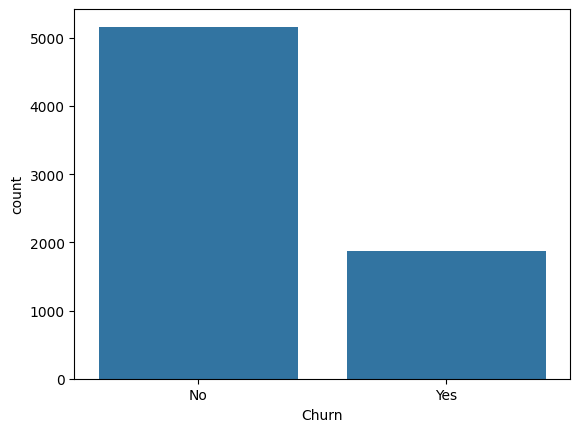

In [19]:
sns.countplot(x="Churn", data=df)
plt.show()

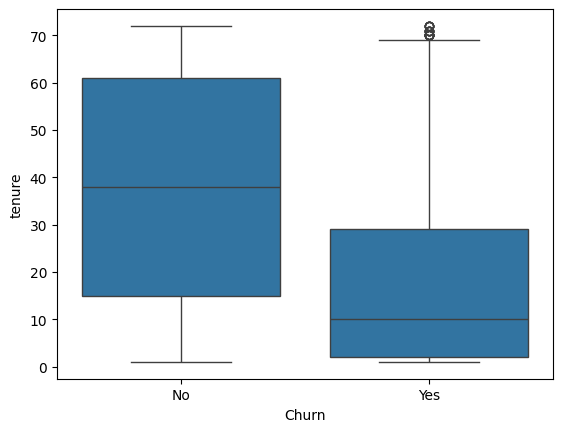

In [20]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

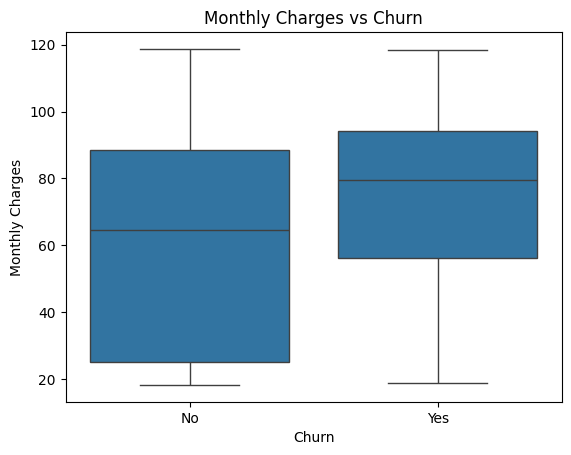

In [21]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

Customers who churned generally have higher monthly charges. The median MonthlyCharges for churned customers is around 80, compared with around 64 for customers who stayed. This suggests that higher monthly charges are associated with a greater tendency to churn in this dataset.

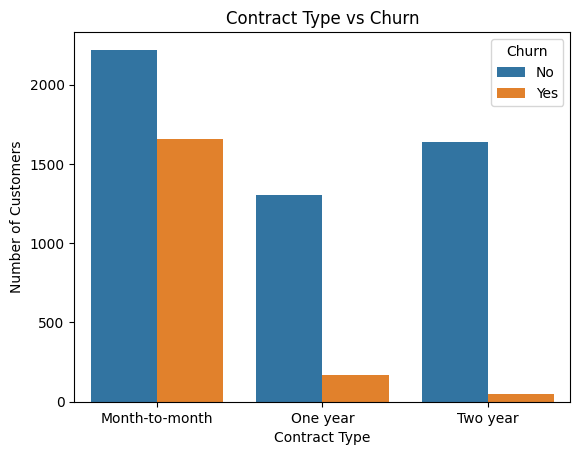

In [22]:
sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [23]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


This suggests the company could focus on:

Encouraging month-to-month customers to move to longer-term contracts.

In [24]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


Fiber optic customers have a substantially higher churn rate than DSL and customers without internet service.

In [25]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


Electronic check is strongly associated with higher churn in this dataset

In [26]:
categorical_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

In [27]:
for col in categorical_cols:
    print("\n", col)
    print(
        pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        ) * 100
    )


 gender
Churn          No        Yes
gender                      
Female  73.040482  26.959518
Male    73.795435  26.204565

 Partner
Churn           No        Yes
Partner                      
No       67.023908  32.976092
Yes      80.282935  19.717065

 Dependents
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.468795  15.531205

 PhoneService
Churn                No        Yes
PhoneService                      
No            75.000000  25.000000
Yes           73.252519  26.747481

 MultipleLines
Churn                    No        Yes
MultipleLines                         
No                74.918759  25.081241
No phone service  75.000000  25.000000
Yes               71.351534  28.648466

 OnlineSecurity
Churn                       No        Yes
OnlineSecurity                           
No                   58.221333  41.778667
No internet service  92.565789   7.434211
Yes                  85.359801  14.640199

 Onlin

Very small difference

| Feature          | Approx. highest vs lowest churn |
| ---------------- | ------------------------------: |
| Partner          |                  33.0% vs 19.7% |
| Dependents       |                  31.3% vs 15.5% |
| PaperlessBilling |                  33.6% vs 16.4% |
| StreamingTV      |                   33.5% vs 7.4% |
| StreamingMovies  |                   33.7% vs 7.4% |


 noticable difference

| Feature          | Highest churn rate |
| ---------------- | -----------------: |
| OnlineSecurity   |         **41.78%** |
| OnlineBackup     |         **39.94%** |
| DeviceProtection |         **39.14%** |
| TechSupport      |         **41.65%** |


strong difference

| Feature          | Highest churn rate |
| ---------------- | -----------------: |
| OnlineSecurity   |         **41.78%** |
| OnlineBackup     |         **39.94%** |
| DeviceProtection |         **39.14%** |
| TechSupport      |         **41.65%** |

from previous anaysis

| Feature         |            Highest churn rate |
| --------------- | ----------------------------: |
| Contract        |   **42.71% — Month-to-month** |
| InternetService |      **41.89% — Fiber optic** |
| PaymentMethod   | **45.29% — Electronic check** |


PRE-PROCESSING

In [28]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
x = df.drop("Churn",axis = 1)
y=df["Churn"]

In [30]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=42, test_size=0.2,stratify=y)

In [31]:
print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(5625, 19)
(1407, 19)
(5625,)
(1407,)


In [32]:
x.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [33]:
num_cols = xtrain.select_dtypes(include=["float64","int64"]).columns
cat_cols = xtrain.select_dtypes(include=["object"]).columns

In [34]:
df.info

<bound method DataFrame.info of       gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL       

In [35]:
print(cat_cols)
print(num_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [36]:
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num",StandardScaler(),num_cols)
    ],
    remainder="passthrough"
)

In [38]:
print(xtrain.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [39]:
xtrain_processed = preprocessor.fit_transform(xtrain)
xtest_processed = preprocessor.transform(xtest)

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix

In [41]:
model_lr = LogisticRegression(random_state=42)

In [42]:
model_lr.fit(xtrain_processed,ytrain)

LogisticRegression(random_state=42)

In [43]:
ypred_lr = model_lr.predict(xtest_processed)

In [44]:
print(accuracy_score(ytest,ypred_lr))
print(confusion_matrix(ytest,ypred_lr))
print(classification_report(ytest,ypred_lr))

0.8038379530916845
[[917 116]
 [160 214]]
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [45]:
from sklearn.metrics import roc_auc_score # another classifation matrics

In [46]:
y_prob_lr = model_lr.predict_proba(xtest_processed)[:, 1]

roc_auc = roc_auc_score(ytest, y_prob_lr)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8359290473207676


In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
model_rf = RandomForestClassifier(random_state=42,n_estimators=100)

In [49]:
model_rf.fit(xtrain_processed,ytrain)

RandomForestClassifier(random_state=42)

In [50]:
ypred_rf=model_rf.predict(xtest_processed)

In [51]:
y_prob_rf = model_rf.predict_proba(xtest_processed)[:, 1]

In [52]:
print(accuracy_score(ytest,ypred_rf))
print(confusion_matrix(ytest,ypred_rf))
print(classification_report(ytest,ypred_rf))
print(roc_auc_score(ytest,y_prob_rf))

0.7910447761194029
[[924 109]
 [185 189]]
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

0.8125016177376522


In [53]:
print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(5625, 19)
(1407, 19)
(5625,)
(1407,)


### Model Comparison and Final Model Selection

Two classification algorithms, Random Forest and Logistic Regression, were trained and evaluated for customer churn prediction.

Random Forest achieved an accuracy of **79.10%**, with a precision of **0.63**, recall of **0.51**, and F1-score of **0.56** for the "Yes" churn class.

Logistic Regression achieved a higher accuracy of **80.38%**, with a precision of **0.65**, recall of **0.57**, and F1-score of **0.61** for the "Yes" churn class.

Since identifying customers who are likely to churn is an important objective, recall and F1-score for the "Yes" class are particularly important. Logistic Regression performed better than Random Forest on accuracy, precision, recall, and F1-score.

Therefore, **Logistic Regression is selected as the final model for customer churn prediction**.


In [54]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names)

45
['cat__gender_Female' 'cat__gender_Male' 'cat__Partner_No'
 'cat__Partner_Yes' 'cat__Dependents_No' 'cat__Dependents_Yes'
 'cat__PhoneService_No' 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__StreamingTV_No'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMovies_No' 'cat__StreamingMovies_No internet service'
 'cat__StreamingMovies_Yes' 'cat__Contract_Month-to-month'
 'cat__Contract_One year' 'cat__Contract_Two year'
 'cat__Paperles

In [55]:
coefficients = model_lr.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = \
    feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
42,num__tenure,-1.352313,1.352313
34,cat__Contract_Two year,-0.779030,0.779030
44,num__TotalCharges,0.644014,0.644014
11,cat__InternetService_DSL,-0.616132,0.616132
32,cat__Contract_Month-to-month,0.613846,0.613846
12,cat__InternetService_Fiber optic,0.590184,0.590184
43,num__MonthlyCharges,-0.541006,0.541006
35,cat__PaperlessBilling_No,-0.300387,0.300387
8,cat__MultipleLines_No,-0.293470,0.293470
15,cat__OnlineSecurity_No internet service,-0.283724,0.283724


In [56]:
from sklearn.pipeline import Pipeline
import joblib

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_lr)
])

final_model.fit(xtrain, ytrain)

joblib.dump(final_model, "churn_model.pkl")

['churn_model.pkl']

In [57]:
import joblib

model = joblib.load("churn_model.pkl")

In [58]:
# new_customer = {
#     "gender": "Female",
#     "SeniorCitizen": 0,
#     "Partner": "Yes",
#     "Dependents": "No",
#     "tenure": 5,
#     "PhoneService": "Yes",
#     "MultipleLines": "No",
#     "InternetService": "Fiber optic",
#     "OnlineSecurity": "No",
#     "OnlineBackup": "No",
#     "DeviceProtection": "No",
#     "TechSupport": "No",
#     "StreamingTV": "Yes",
#     "StreamingMovies": "Yes",
#     "Contract": "Month-to-month",
#     "PaperlessBilling": "Yes",
#     "PaymentMethod": "Electronic check",
#     "MonthlyCharges": 85.5,
#     "TotalCharges": 427.5
# }

new_customer = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "Yes",
    "tenure": 60,
    "PhoneService": "Yes",
    "MultipleLines": "Yes",
    "InternetService": "DSL",
    "OnlineSecurity": "Yes",
    "OnlineBackup": "Yes",
    "DeviceProtection": "Yes",
    "TechSupport": "Yes",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Two year",
    "PaperlessBilling": "No",
    "PaymentMethod": "Bank transfer (automatic)",
    "MonthlyCharges": 55.0,
    "TotalCharges": 3300.0
}

In [59]:
import pandas as pd

new_customer_df = pd.DataFrame([new_customer])

In [60]:
prediction = model.predict(new_customer_df)

print(prediction)

['No']


In [61]:
probability = model.predict_proba(new_customer_df)

print(probability)

[[0.99385218 0.00614782]]


In [62]:
print("Churn Probability:", probability[0][1])

Churn Probability: 0.006147815981589825


In [63]:
print(ytrain.unique())

['No' 'Yes']


In [64]:
print(final_model.classes_)

['No' 'Yes']


In [65]:
probability[0][1]

np.float64(0.006147815981589825)

In [66]:
print(final_model.classes_)
print(prediction)
print(probability)

['No' 'Yes']
['No']
[[0.99385218 0.00614782]]


AI-INTEGRATION

In [67]:
# Get feature names after preprocessing
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = final_model.named_steps["model"].coef_[0]

# Create a dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Calculate absolute importance
feature_importance["Importance"] = feature_importance["Coefficient"].abs()

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Importance
42,num__tenure,-1.352313,1.352313
34,cat__Contract_Two year,-0.779030,0.779030
44,num__TotalCharges,0.644014,0.644014
11,cat__InternetService_DSL,-0.616132,0.616132
32,cat__Contract_Month-to-month,0.613846,0.613846
12,cat__InternetService_Fiber optic,0.590184,0.590184
43,num__MonthlyCharges,-0.541006,0.541006
35,cat__PaperlessBilling_No,-0.300387,0.300387
8,cat__MultipleLines_No,-0.293470,0.293470
15,cat__OnlineSecurity_No internet service,-0.283724,0.283724


The coefficient indicates the direction and strength of the feature's contribution to the model's prediction, holding the other features constant

In [68]:
feature_importance.head(10)

,Feature,Coefficient,Importance
42,num__tenure,-1.352313,1.352313
34,cat__Contract_Two year,-0.779030,0.779030
44,num__TotalCharges,0.644014,0.644014
11,cat__InternetService_DSL,-0.616132,0.616132
32,cat__Contract_Month-to-month,0.613846,0.613846
12,cat__InternetService_Fiber optic,0.590184,0.590184
43,num__MonthlyCharges,-0.541006,0.541006
35,cat__PaperlessBilling_No,-0.300387,0.300387
8,cat__MultipleLines_No,-0.293470,0.293470
15,cat__OnlineSecurity_No internet service,-0.283724,0.283724
